## A cascade from one initial startle

One fish starts actively escaping at time zero. All other fish begin
unsheltered, with zero evidence. Subsequent escapes are driven by social doses.

Each fish's evidence is the sum of doses remembered within
`memory_duration`. An unsheltered fish escapes when this exceeds its own
fixed threshold, stored as `fish.threshold`.
It sends doses for `active_duration`, then enters absorbing shelter.

The states are `0` (unsheltered), `1` (active), and `2` (sheltered).
Each fish can escape at most once during a run.

Parameters, initialization, the update loop, and plots are shown below.
Run the notebook from the top to initialize a fresh school.
[dose_memory.ipynb](dose_memory.ipynb) explains the dose and memory functions.


In [1]:
from importlib import reload

import numpy as np
import matplotlib.pyplot as plt

import agent
import stimulus

reload(agent)
reload(stimulus)
from agent import Agent
from stimulus import spontaneous_startle
from dose import draw_doses, accumulate_doses
from network import random_network

In [2]:
## Group size and observation window
n_fish = 20
total_time = 1.0
dt = 0.001

In [3]:
## Mean escape threshold and active phase
mean_threshold = 0.034
active_duration = 0.5
random_seed = 2026

In [4]:
## Social dose arrivals and memory
dose_rate = 1000.0
dose_size = 0.001
memory_duration = 2.0

Time and history columns run from `0` through `n_steps - 1`.
Column zero stores the initialized school. Each later column stores the result
of one update, so there are `n_steps - 1` updates.


In [5]:
n_steps = round(total_time / dt)
time = np.arange(n_steps) * dt
active_steps = max(1, round(active_duration / dt))
memory_steps = max(1, round(memory_duration / dt))

## Social interactions

`adjacency[i, j]` is the connection weight from fish `j` to fish `i`.
The random network connects pairs in both directions and has no self-input.
Its random seed is independent of starter selection and dose arrivals.

An active neighbour sends a packet with probability
`dose_rate * adjacency[i, j] * dt`. Each packet contributes `dose_size`
divided by the receiver's number of incoming neighbours, including inactive
neighbours. The probability must be at most one. With the current binary
weights and dose settings, every active connection sends a packet each update;
fractional weights make arrivals stochastic.

The adjacency matrix can be edited in the cell below. Positions do not enter
this illustrative network; it is not an empirical Sosna network.


In [6]:
connection_probability = 0.2
network_seed = 2026

In [7]:
adjacency = random_network(n_fish, connection_probability, network_seed)

In [8]:
evidence_history = np.zeros((n_fish, n_steps))
escape_spikes = np.zeros((n_fish, n_steps))
state_history = np.zeros((n_fish, n_steps))
dose_history = np.zeros((n_fish, n_steps))

## Individual escape thresholds

Each fish receives one threshold drawn uniformly between zero and
`2 * mean_threshold`. Its threshold stays fixed throughout the run.

`mean_threshold` is the expected mean of this distribution, not the average
dose received and not necessarily the mean of this particular sample of fish.
The default `mean_threshold = 0.034` comes from Sosna et al.'s SI Section 6.3,
page 9: Context 1, the baseline before first exposure, used in Figure 4D.
Its reported 95% credible interval is [0.030, 0.035]. This is a fitted value
for their empirical networks, used here as a reference for our random network.

The threshold generator is separate from the starter and dose generators.
Rerunning from the top with the same seed reproduces the same thresholds.


In [9]:
threshold_rng = np.random.default_rng([random_seed, 2])
thresholds = threshold_rng.uniform(0.0, 2 * mean_threshold, n_fish)

## One initial startle

`spontaneous_startle` in [stimulus.py](stimulus.py) sets one fish's state to
active, gives it the full active timer, and returns its index.

`initial_fish = None` selects a random fish. An integer selects that fish
instead, which allows a known experimental starter to be used later.
This function is called once, during initialization. Its random generator is
separate from the dose generator, so starter selection does not consume dose draws.


In [10]:
agents = [Agent(threshold) for threshold in thresholds]
startle_rng = np.random.default_rng([random_seed, 0])
dose_rng = np.random.default_rng([random_seed, 1])

In [11]:
initial_fish = None
starter_id = spontaneous_startle(agents, active_steps, startle_rng, initial_fish)
state_history[:, 0] = [fish.state for fish in agents]
escape_spikes[starter_id, 0] = 1

## Propagate the cascade

Doses use the active states from the preceding column. A newly activated fish
first supplies doses on the next update. For an onset at column `k`, the fish
is recorded active through `k + active_steps - 1`, sends doses on updates
`k + 1` through `k + active_steps`, then enters shelter.

Each dose retains its full contribution for `memory_steps` updates.
Evidence is recorded in every state, but only unsheltered fish can activate.
Sheltered fish remain sheltered and send no doses.


In [12]:
for step in range(1, n_steps):
    active = np.array([fish.state == 1 for fish in agents])
    dose_history[:, step] = draw_doses(
        adjacency, active, dt, dose_rate, dose_size, dose_rng,
    )
    social_evidence = accumulate_doses(dose_history, step, memory_steps)
    for fish_id, fish in enumerate(agents):
        fish.evidence = social_evidence[fish_id]
        if fish.state == 0:
            if fish.evidence > fish.threshold:
                fish.state = 1
                fish.active_timer = active_steps
                escape_spikes[fish_id, step] = 1
        elif fish.state == 1:
            fish.active_timer -= 1
            if fish.active_timer == 0:
                fish.state = 2
        evidence_history[fish_id, step] = fish.evidence
        state_history[fish_id, step] = fish.state

## Social evidence over time

The starter is activated directly, so it does not need to cross the threshold.
Other fish escape only when their remembered social evidence exceeds their
own threshold. There is no shared threshold line; `thresholds` contains the
fixed values in fish-index order.


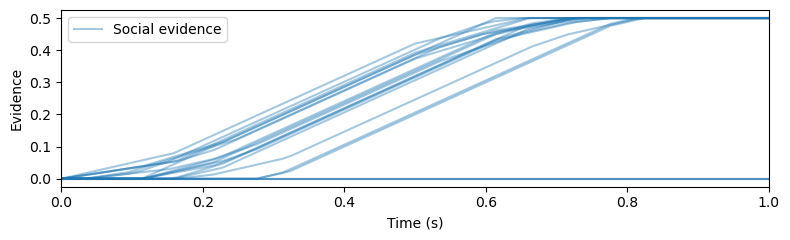

In [13]:
fig, ax = plt.subplots(figsize=(8, 2.5))
lines = ax.plot(time, evidence_history.T, color="tab:blue", alpha=0.4)
lines[0].set_label("Social evidence")
ax.set(xlim=(0, total_time), xlabel="Time (s)", ylabel="Evidence")
ax.legend()
fig.tight_layout()
plt.show()

## Escape onsets

The mark at time zero is the initial startle. Later marks are responses to
social doses. Each fish can have at most one mark during the run.


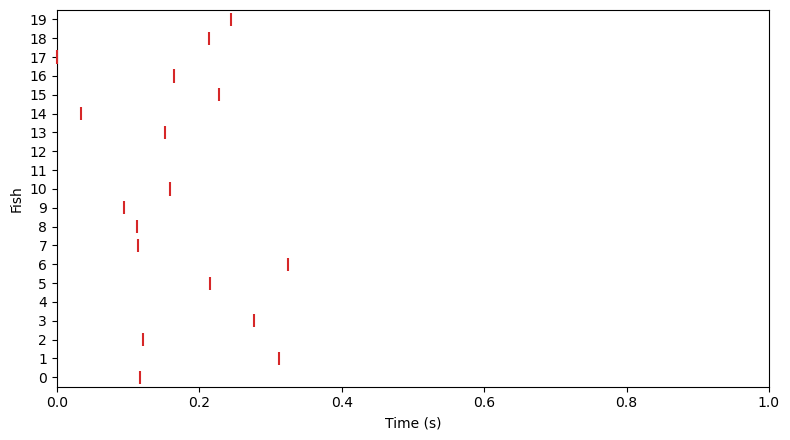

In [14]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for fish_id in range(n_fish):
    escape_times = time[escape_spikes[fish_id] == 1]
    ax.vlines(escape_times, fish_id - 0.35, fish_id + 0.35, color="tab:red",
              zorder=3, clip_on=False)
ax.set(xlim=(0, total_time), ylim=(-0.5, n_fish - 0.5))
ax.set(xlabel="Time (s)", ylabel="Fish", yticks=np.arange(n_fish))
fig.tight_layout()
plt.show()

## Behavioral state

Only active fish send doses. Black markers show shelter entry; each fish
then stays sheltered for the rest of the run.

The observation window can end before late escapes finish their active phases.
The run still uses a fixed duration, an illustrative mean threshold, and an
illustrative network. The [guide](README.md#reproducing-sosna-et-al-2019) lists the remaining
steps toward reproducing Sosna's results.


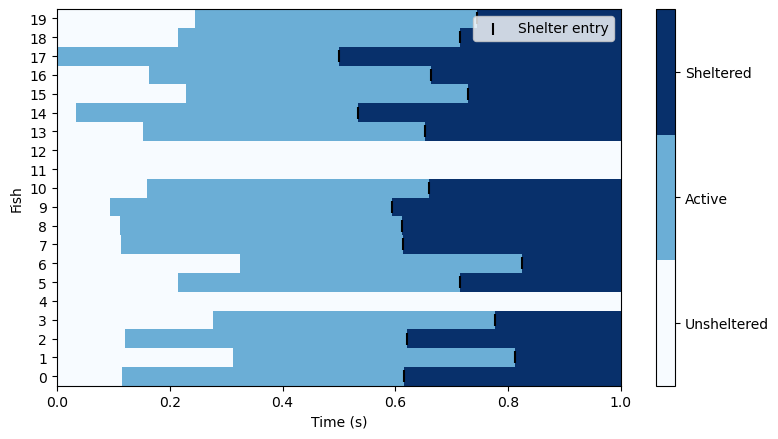

In [15]:
fig, ax = plt.subplots(figsize=(8, 4.5))
image = ax.imshow(state_history, origin="lower", aspect="auto",
                  extent=(0, total_time, -0.5, n_fish - 0.5),
                  cmap=plt.get_cmap("Blues", 3), vmin=-0.5, vmax=2.5,
                  interpolation="nearest")
shelter_entries = (state_history[:, 1:] == 2) & (state_history[:, :-1] != 2)
fish_ids, entry_steps = np.where(shelter_entries)
ax.scatter(time[entry_steps + 1], fish_ids, marker="|", color="black",
           s=70, label="Shelter entry")
ax.set(xlabel="Time (s)", ylabel="Fish", yticks=np.arange(n_fish))
ax.legend(loc="upper right")
colorbar = fig.colorbar(image, ax=ax, ticks=[0, 1, 2])
colorbar.ax.set_yticklabels(["Unsheltered", "Active", "Sheltered"])
fig.tight_layout()
plt.show()